In [ ]:
import torch
import imageio
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Install required libraries
!pip install gymnasium highway-env stable-baselines3 torch matplotlib imageio

# For video rendering
!apt-get install -y ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 9.6 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving racetrack_sac_model.zip to racetrack_sac_model.zip


In [ ]:
import os
print(os.listdir())

['.config', 'racetrack_sac_model.zip', 'sample_data']


In [ ]:
from stable_baselines3.common.env_util import make_vec_env

env_kwargs = {
    "config": {
        "terminate_off_road": True,
        "lane_centering_cost": 0.0,
        "action_reward": -0.1,
        "observation": {
            "type": "OccupancyGrid",
            "features": ["presence", "on_road"],
            "grid_size": [[-18, 18], [-18, 18]],
            "grid_step": [1, 1],
            "align_to_vehicle_axes": True
        },
        "screen_width": 530,
        "screen_height": 300,
        "scaling": 3.5,
    }
}

env = make_vec_env('racetrack-v0', n_envs=1, env_kwargs=env_kwargs)

In [ ]:
import gymnasium as gym
from stable_baselines3 import SAC

model = SAC.load("racetrack_sac_model.zip", env=env)
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
import highway_env   # IMPORTANT: registers the environments

gym.register_envs(highway_env)

env = gym.make('racetrack-v0')

policy_freq = env.unwrapped.config["policy_frequency"]
simulation_freq = env.unwrapped.config["simulation_frequency"]

env.close()

print("Policy frequency:", policy_freq)
print("Simulation frequency:", simulation_freq)

# 20 second episode
max_steps = int(20 * policy_freq)
print("Max steps per rollout:", max_steps)

Policy frequency: 5
Simulation frequency: 15
Max steps per rollout: 100


In [ ]:
def compute_nominal_logprob(model, obs, action):
    obs_tensor = torch.tensor(obs).float().unsqueeze(0)
    dist = model.policy.actor.get_distribution(obs_tensor)
    action_tensor = torch.tensor(action).float().unsqueeze(0)
    log_prob = dist.log_prob(action_tensor)
    return log_prob.sum().item()

In [38]:
def run_rollout(env, model, action_variance_scale=1.0):
    obs, info = env.reset()
    done, truncated = False, False
    logp_nom = 0.0
    frames = []
    step = 0

    while not (done or truncated) and step < max_steps:
        frames.append(env.render())

        # Get deterministic action from the policy
        action, _ = model.predict(obs, deterministic=True)

        # Add Gaussian noise for fuzzing
        noise = np.random.normal(0, action_variance_scale, size=action.shape)
        action_noisy = np.clip(action + noise, env.action_space.low, env.action_space.high)

        # Approximate log-probability under nominal (deterministic) policy
        logp_nom += -0.5 * np.sum(((action_noisy - action) / action_variance_scale) ** 2)

        obs, reward, done, truncated, info = env.step(action_noisy)
        step += 1

    failed = done
    return failed, logp_nom, frames

In [32]:
device = model.device

In [39]:
variance_scales = np.linspace(1.0, 3.0, 5)
vehicle_counts = [5, 10, 15, 20]

best_logp = -np.inf
best_video = None
failure_logps = []

for var_scale in variance_scales:
    for num_vehicles in vehicle_counts:
        print(f"Testing variance={var_scale}, vehicles={num_vehicles}")

        # Reset environment with new number of vehicles
        env_vec = make_vec_env('racetrack-v0', n_envs=1, env_kwargs=env_kwargs)
        env_single = env_vec.envs[0]  # underlying single environment
        env_single.unwrapped.config["other_vehicles"] = num_vehicles

        # Run multiple rollouts
        for i in range(10):
            failed, logp, frames = run_rollout(env_single, model, action_variance_scale=var_scale)

            if failed:
                failure_logps.append(logp)

                if logp > best_logp:
                    best_logp = logp
                    best_video = frames

        env_vec.close()

print("Most Likely Failure logP:", best_logp)

if best_video is not None:
    imageio.mimsave("Most_Likely_Failure.mp4", best_video, fps=20)
    print("Saved Most_Likely_Failure.mp4")

Testing variance=1.0, vehicles=5
Testing variance=1.0, vehicles=10
Testing variance=1.0, vehicles=15
Testing variance=1.0, vehicles=20
Testing variance=1.5, vehicles=5
Testing variance=1.5, vehicles=10
Testing variance=1.5, vehicles=15
Testing variance=1.5, vehicles=20
Testing variance=2.0, vehicles=5
Testing variance=2.0, vehicles=10
Testing variance=2.0, vehicles=15
Testing variance=2.0, vehicles=20
Testing variance=2.5, vehicles=5
Testing variance=2.5, vehicles=10
Testing variance=2.5, vehicles=15
Testing variance=2.5, vehicles=20
Testing variance=3.0, vehicles=5
Testing variance=3.0, vehicles=10
Testing variance=3.0, vehicles=15
Testing variance=3.0, vehicles=20
Most Likely Failure logP: -0.033652939422965905


Saved Most_Likely_Failure.mp4


In [40]:
from IPython.display import Video
Video("Most_Likely_Failure.mp4", embed=True)

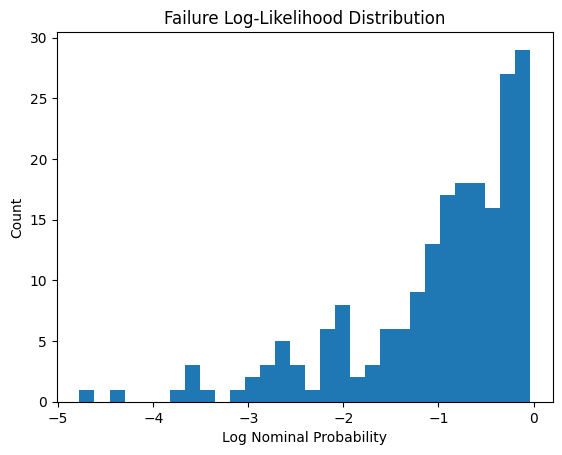

In [41]:
plt.hist(failure_logps, bins=30)
plt.title("Failure Log-Likelihood Distribution")
plt.xlabel("Log Nominal Probability")
plt.ylabel("Count")
plt.show()

In [45]:
# ======= Step 1: Sweep individual proposals =======
action_mlf_metrics = {}  # variance_scale -> most likely failure logp
env_mlf_metrics = {}     # num_vehicles -> most likely failure logp
best_logp = -np.inf
best_video = None
best_config = (None, None)

# Sweep action variance
for var_scale in variance_scales:
    print(f"Testing action variance scale={var_scale:.2f}")
    env_vec = make_vec_env('racetrack-v0', n_envs=1, env_kwargs=env_kwargs)
    env_single = env_vec.envs[0]

    logps = []
    for _ in range(num_rollouts_per_setting):
        failed, logp, frames = run_rollout(env_single, model, action_variance_scale=var_scale)
        if failed:
            logps.append(logp)
            if logp > best_logp:
                best_logp = logp
                best_video = frames
                best_config = (env_single.unwrapped.config["other_vehicles"], var_scale)
    if logps:
        action_mlf_metrics[var_scale] = max(logps)
    env_vec.close()

# Pick optimal variance from sweep
variance_scale_opt = max(action_mlf_metrics, key=action_mlf_metrics.get)
print(f"Optimal action variance scale: {variance_scale_opt:.2f}")

# Sweep number of vehicles using optimal variance
for num_vehicles in vehicle_counts:
    print(f"Testing number of vehicles={num_vehicles}")
    env_vec = make_vec_env('racetrack-v0', n_envs=1, env_kwargs=env_kwargs)
    env_single = env_vec.envs[0]
    env_single.unwrapped.config["other_vehicles"] = num_vehicles

    logps = []
    for _ in range(num_rollouts_per_setting):
        failed, logp, frames = run_rollout(env_single, model, action_variance_scale=variance_scale_opt)
        if failed:
            logps.append(logp)
            if logp > best_logp:
                best_logp = logp
                best_video = frames
                best_config = (num_vehicles, variance_scale_opt)
    if logps:
        env_mlf_metrics[num_vehicles] = max(logps)
    env_vec.close()

# Pick optimal number of vehicles
num_vehicles_opt = max(env_mlf_metrics, key=env_mlf_metrics.get)
print(f"Optimal number of vehicles: {num_vehicles_opt}")
print(f"Global Most Likely Failure logP: {best_logp:.2f}")
print(f"Produced by configuration: num_vehicles={best_config[0]}, variance_scale={best_config[1]:.2f}")

Testing action variance scale=0.50
Testing action variance scale=0.73
Testing action variance scale=0.95
Testing action variance scale=1.18
Testing action variance scale=1.41
Testing action variance scale=1.64
Testing action variance scale=1.86
Testing action variance scale=2.09
Testing action variance scale=2.32
Testing action variance scale=2.55
Testing action variance scale=2.77
Testing action variance scale=3.00
Optimal action variance scale: 3.00
Testing number of vehicles=5
Testing number of vehicles=7
Testing number of vehicles=9
Testing number of vehicles=11
Testing number of vehicles=13
Testing number of vehicles=15
Testing number of vehicles=17
Testing number of vehicles=19
Testing number of vehicles=21
Testing number of vehicles=23
Testing number of vehicles=25
Optimal number of vehicles: 9
Global Most Likely Failure logP: -0.02
Produced by configuration: num_vehicles=9, variance_scale=3.00


Testing action variance scale=0.50
Testing action variance scale=0.73
Testing action variance scale=0.95
Testing action variance scale=1.18
Testing action variance scale=1.41
Testing action variance scale=1.64
Testing action variance scale=1.86
Testing action variance scale=2.09
Testing action variance scale=2.32
Testing action variance scale=2.55
Testing action variance scale=2.77
Testing action variance scale=3.00
Testing number of vehicles=5
Testing number of vehicles=7
Testing number of vehicles=9
Testing number of vehicles=11
Testing number of vehicles=13
Testing number of vehicles=15
Testing number of vehicles=17
Testing number of vehicles=19
Testing number of vehicles=21
Testing number of vehicles=23
Testing number of vehicles=25
Global Most Likely Failure logP: -0.02
Produced by configuration: num_vehicles=11, variance_scale=3.00


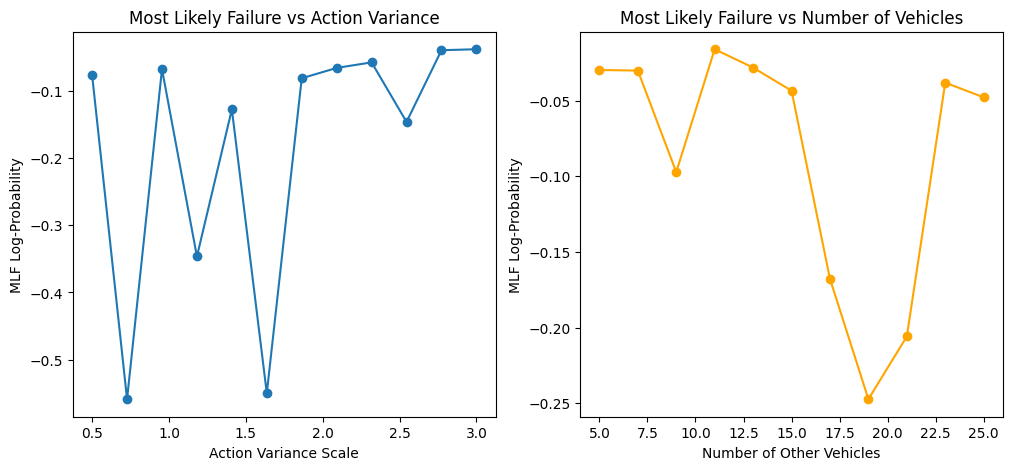

Saved MLF_after_25_steps.mp4


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from stable_baselines3.common.env_util import make_vec_env

# ======= Parameters =======
variance_scales = np.linspace(0.5, 3.0, 12)   # finer range for action noise
vehicle_counts = np.arange(5, 26, 2)          # 5 to 25 vehicles
num_rollouts_per_setting = 10

# ======= Storage =======
action_mlf_metrics = {}   # variance_scale -> most likely failure logp
env_mlf_metrics = {}      # num_vehicles -> most likely failure logp
best_logp = -np.inf
best_video = None
best_config = (None, None)

# ======= Sweep individual proposals =======
for var_scale in variance_scales:
    print(f"Testing action variance scale={var_scale:.2f}")
    env_vec = make_vec_env('racetrack-v0', n_envs=1, env_kwargs=env_kwargs)
    env_single = env_vec.envs[0]

    logps = []
    for _ in range(num_rollouts_per_setting):
        failed, logp, frames = run_rollout(env_single, model, action_variance_scale=var_scale)
        if failed:
            logps.append(logp)
            if logp > best_logp:
                best_logp = logp
                best_video = frames
                best_config = (env_single.unwrapped.config["other_vehicles"], var_scale)
    if logps:
        action_mlf_metrics[var_scale] = max(logps)
    env_vec.close()

for num_vehicles in vehicle_counts:
    print(f"Testing number of vehicles={num_vehicles}")
    env_vec = make_vec_env('racetrack-v0', n_envs=1, env_kwargs=env_kwargs)
    env_single = env_vec.envs[0]
    env_single.unwrapped.config["other_vehicles"] = num_vehicles

    logps = []
    for _ in range(num_rollouts_per_setting):
        failed, logp, frames = run_rollout(env_single, model, action_variance_scale=variance_scale_opt)
        if failed:
            logps.append(logp)
            if logp > best_logp:
                best_logp = logp
                best_video = frames
                best_config = (num_vehicles, variance_scale_opt)
    if logps:
        env_mlf_metrics[num_vehicles] = max(logps)
    env_vec.close()

print(f"Global Most Likely Failure logP: {best_logp:.2f}")
print(f"Produced by configuration: num_vehicles={best_config[0]}, variance_scale={best_config[1]:.2f}")

# ======= Plot MLF likelihoods =======
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(list(action_mlf_metrics.keys()), list(action_mlf_metrics.values()), marker='o')
plt.xlabel("Action Variance Scale")
plt.ylabel("MLF Log-Probability")
plt.title("Most Likely Failure vs Action Variance")

plt.subplot(1,2,2)
plt.plot(list(env_mlf_metrics.keys()), list(env_mlf_metrics.values()), marker='o', color='orange')
plt.xlabel("Number of Other Vehicles")
plt.ylabel("MLF Log-Probability")
plt.title("Most Likely Failure vs Number of Vehicles")
plt.show()

In [48]:
# ======= Interesting failures after thresholds =======
thresholds = [0, 25, 50, 75]  # timesteps
mlf_videos = {}
env_vec = make_vec_env('racetrack-v0', n_envs=1, env_kwargs=env_kwargs)
env_single = env_vec.envs[0]
env_single.unwrapped.config["other_vehicles"] = best_config[0]

for t_thresh in thresholds:
    best_logp_thresh = -np.inf
    best_video_thresh = None
    for _ in range(num_rollouts_per_setting*2):
        failed, logp, frames = run_rollout(env_single, model, action_variance_scale=best_config[1])
        if failed and len(frames) > t_thresh and logp > best_logp_thresh:
            best_logp_thresh = logp
            best_video_thresh = frames
    mlf_videos[t_thresh] = best_video_thresh

env_vec.close()

# Save thresholded MLF videos
for t, video in mlf_videos.items():
    if video is not None:
        fname = f"MLF_after_{t}_steps.mp4"
        imageio.mimsave(fname, video, fps=20)
        print(f"Saved {fname}")

Saved MLF_after_0_steps.mp4
Saved MLF_after_25_steps.mp4


In [49]:
from IPython.display import Video
Video("MLF_after_0_steps.mp4", embed=True)

In [ ]:
from IPython.display import Video
Video("MLF_after_50_steps.mp4", embed=True)

In [ ]:
from IPython.display import Video
Video("MLF_after_75_steps.mp4", embed=True)